# Notebook 02 — Data Split & DataLoader Verification
**Run after:** `01_eda.ipynb`

This notebook:
1. Performs the group-based train/val/test split (prevents data leakage)
2. Creates DataLoaders with weighted sampling
3. Loads **one real batch** and prints exactly what comes out
4. Visualizes one augmented batch vs one clean batch


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')
import warnings; warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

from data.dataset import (
    load_metadata, split_dataset, get_dataloaders,
    CLASS_NAMES, IDX_TO_CLASS, DISPLAY_NAMES
)

METADATA_CSV = 'dataset/HAM10000_metadata.csv'
IMAGES_DIR   = 'dataset/images'
OUTPUTS_DIR  = 'outputs'

df = load_metadata(METADATA_CSV, IMAGES_DIR)
print(f"Loaded {len(df):,} images")


STEP 1B: Loading HAM10000 Metadata
  Total records in CSV: 10015
  Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']
  Unique lesions (lesion_id): 7470
  Unique images (image_id):   10015
  All 10015 images found on disk. ✅

  Class distribution:
    akiec  (Actinic Keratosis        ):   327 (3.3%)
    bcc    (Basal Cell Carcinoma     ):   514 (5.1%)
    bkl    (Benign Keratosis         ):  1099 (11.0%)
    df     (Dermatofibroma           ):   115 (1.1%)
    mel    (Melanoma                 ):  1113 (11.1%)
    nv     (Melanocytic Nevus        ):  6705 (66.9%)
    vasc   (Vascular Lesion          ):   142 (1.4%)
Loaded 10,015 images


## Group-Based Train / Val / Test Split
The key decision: split by **lesion_id**, not by image index.
This guarantees no image of the same lesion appears in two different splits.


In [2]:
df_train, df_val, df_test = split_dataset(df)

print(f"{'Split':<8} {'Images':>8} {'Lesions':>10} {'% of total':>12}")
print(f"{'─'*8} {'─'*8} {'─'*10} {'─'*12}")
for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pct = 100 * len(d) / len(df)
    print(f"{name:<8} {len(d):>8,} {d['lesion_id'].nunique():>10,} {pct:>11.1f}%")

# Verify no leakage
train_l = set(df_train['lesion_id']); val_l = set(df_val['lesion_id']); test_l = set(df_test['lesion_id'])
assert len(train_l & val_l) == 0 and len(train_l & test_l) == 0
print("\n✅ Zero leakage across all splits")



STEP 1C: Group-Based Train/Val/Test Split
WHY: Splitting by lesion_id prevents same lesion in train+test
  Train:  6959 images | 5228 unique lesions
  Val:    1529 images | 1121 unique lesions
  Test:   1527 images | 1121 unique lesions
  No data leakage detected ✅
Split      Images    Lesions   % of total
──────── ──────── ────────── ────────────
Train       6,959      5,228        69.5%
Val         1,529      1,121        15.3%
Test        1,527      1,121        15.2%

✅ Zero leakage across all splits


## Class Distribution Per Split

In [3]:
import pandas as pd

rows = []
for cls_code, idx in sorted(CLASS_NAMES.items(), key=lambda x: x[1]):
    rows.append({
        'Class': cls_code,
        'Train': int((df_train['label'] == idx).sum()),
        'Val':   int((df_val['label']   == idx).sum()),
        'Test':  int((df_test['label']  == idx).sum()),
    })
pd.DataFrame(rows).set_index('Class')


,Train,Val,Test
Class,,,
nv,4662,1027,1016
mel,771,156,186
bkl,770,157,172
bcc,349,99,66
akiec,222,57,48
vasc,93,20,29
df,92,13,10


## Build DataLoaders

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    df_train, df_val, df_test, batch_size=16
)
print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")
print(f"\nTrain uses weighted sampling → rare classes seen equally")
print(f"Val/Test use natural distribution → honest evaluation")



STEP 1G: Creating DataLoaders
  Batch size: 16 (safe for M2 8GB)

  Class weights for sampler:
    nv    :  4662 samples → weight 1.49
    mel   :   771 samples → weight 9.03
    bkl   :   770 samples → weight 9.04
    bcc   :   349 samples → weight 19.94
    akiec :   222 samples → weight 31.35
    vasc  :    93 samples → weight 74.83
    df    :    92 samples → weight 75.64
  Train batches:      434
  Validation batches: 48
  Test batches:       48
Train batches:      434
Validation batches: 48
Test batches:       48

Train uses weighted sampling → rare classes seen equally
Val/Test use natural distribution → honest evaluation


## Inspect One Real Batch
This is what your model receives during training.
Shapes, dtype, value ranges, metadata — everything verified here.


In [5]:
images, labels, meta = next(iter(train_loader))

print("=== TRAINING BATCH ===")
print(f"images.shape : {images.shape}  → (batch, channels, H, W)")
print(f"images.dtype : {images.dtype}")
print(f"pixel range  : [{images.min():.2f}, {images.max():.2f}]  (negative is normal after ImageNet norm)")
print(f"labels.shape : {labels.shape}")
print(f"labels       : {labels.tolist()}")
print(f"class names  : {[IDX_TO_CLASS[l.item()] for l in labels]}")
print(f"\nmeta keys    : {list(meta.keys())}")
print(f"sample image_id    : {meta['image_id'][0]}")
print(f"sample age         : {meta['age'][0].item():.0f}")
print(f"sample localization: {meta['localization'][0]}")

print("\nClass counts in this batch (weighted sampling in action):")
for cls_idx, count in sorted(Counter(l.item() for l in labels).items()):
    print(f"  {IDX_TO_CLASS[cls_idx]:<8}: {'█'*count} ({count})")


=== TRAINING BATCH ===
images.shape : torch.Size([16, 3, 224, 224])  → (batch, channels, H, W)
images.dtype : torch.float32
pixel range  : [-2.12, 2.64]  (negative is normal after ImageNet norm)
labels.shape : torch.Size([16])
labels       : [3, 6, 5, 0, 2, 4, 4, 5, 1, 4, 0, 1, 2, 3, 0, 2]
class names  : ['bcc', 'df', 'vasc', 'nv', 'bkl', 'akiec', 'akiec', 'vasc', 'mel', 'akiec', 'nv', 'mel', 'bkl', 'bcc', 'nv', 'bkl']

meta keys    : ['image_id', 'lesion_id', 'age', 'sex', 'localization', 'dx_type']
sample image_id    : ISIC_0025299
sample age         : 70
sample localization: back

Class counts in this batch (weighted sampling in action):
  nv      : ███ (3)
  mel     : ██ (2)
  bkl     : ███ (3)
  bcc     : ██ (2)
  akiec   : ███ (3)
  vasc    : ██ (2)
  df      : █ (1)


## Visualize Augmented vs Clean Batch

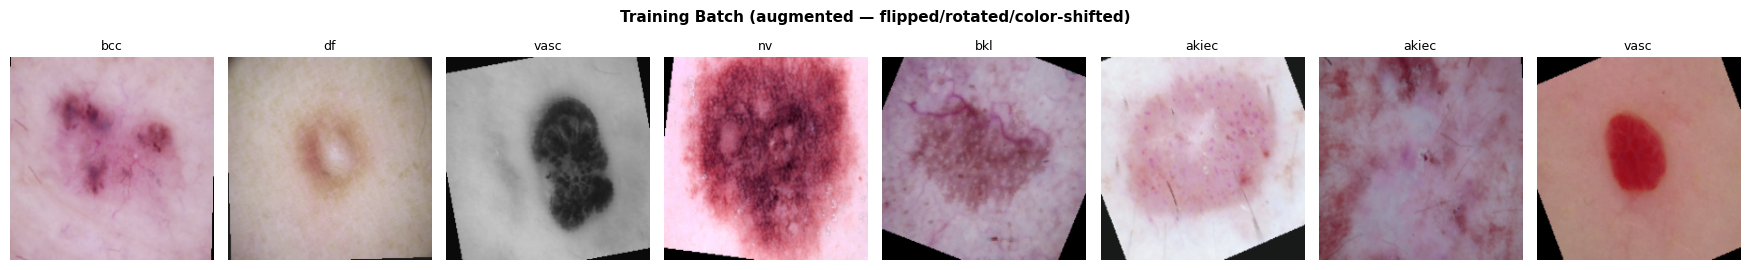

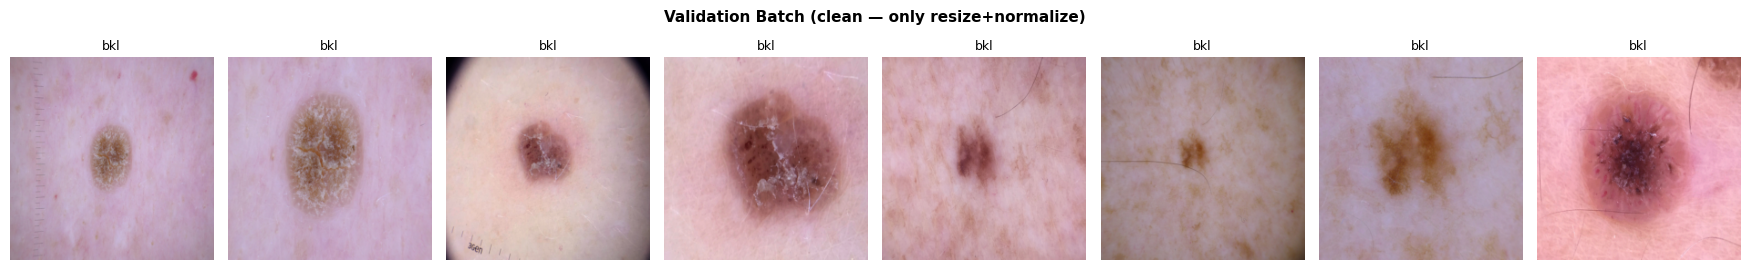


→ NEXT: Open notebook 03_build_model.ipynb


In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def show_batch(imgs, lbls, title, n=8):
    fig, axes = plt.subplots(1, n, figsize=(n*2.2, 2.8))
    fig.suptitle(title, fontsize=11, fontweight='bold')
    for i in range(n):
        img = imgs[i].permute(1,2,0).numpy()
        img = np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(IDX_TO_CLASS[lbls[i].item()], fontsize=9)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Training batch — notice flips, rotations, color shifts
show_batch(images, labels, "Training Batch (augmented — flipped/rotated/color-shifted)")

# Val batch — clean, no augmentation
val_imgs, val_lbls, _ = next(iter(val_loader))
show_batch(val_imgs, val_lbls, "Validation Batch (clean — only resize+normalize)")

print("\n→ NEXT: Open notebook 03_build_model.ipynb")
